# RabTech Academy - ML Baseline Model

## Customer Churn Prediction

**Internship:** Artificial Intelligence & Machine Learning  
**Task:** ML Problem Framing & Responsible Data Card

### Objective

Develop a simple machine learning baseline for predicting customer
churn and compare it with a non-ML majority-class baseline.

### Dataset

Customer Churn Training Dataset.

### Important Limitation

The supplied dataset contains only 12 customer records. Therefore,
the results are educational and should not be considered evidence of
production-level model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/customer-churn-training.csv")

df

,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned
0,C001,2,4,499,21,Basic,1
1,C002,18,1,1299,2,Pro,0
2,C003,6,3,799,14,Basic,1
3,C004,30,0,1499,1,Pro,0
4,C005,11,2,999,5,Standard,0
5,C006,1,5,499,30,Basic,1
6,C007,24,1,999,3,Standard,0
7,C008,8,4,799,17,Basic,1
8,C009,15,2,1299,4,Pro,0
9,C010,4,3,499,12,Basic,1


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 12
Number of columns: 7


In [4]:
print("Columns:")
print(df.columns.tolist())

Columns:
['customer_id', 'tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type', 'churned']


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customer_id          0
tenure_months        0
support_tickets      0
monthly_spend_inr    0
last_login_days      0
plan_type            0
churned              0
dtype: int64


In [6]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [7]:
print("Churn Distribution:")
print(df["churned"].value_counts())

print("\nChurn Percentage:")
print(
    (df["churned"].value_counts(normalize=True) * 100).round(2)
)

Churn Distribution:
churned
0    7
1    5
Name: count, dtype: int64

Churn Percentage:
churned
0    58.33
1    41.67
Name: proportion, dtype: float64


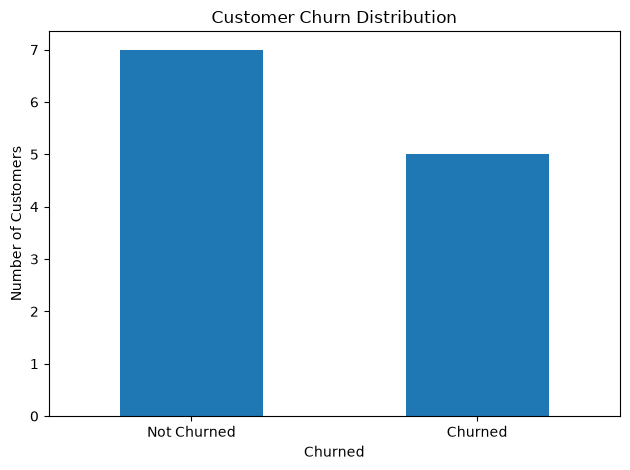

In [8]:
df["churned"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")
plt.xticks(
    [0, 1],
    ["Not Churned", "Churned"],
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "../outputs/class_distribution.png",
    dpi=300
)

plt.show()

In [9]:
X = df.drop(
    columns=["customer_id", "churned"]
)

y = df["churned"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("churned")

Features:
['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type']

Target:
churned


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numerical features
numeric_features = [
    "tenure_months",
    "support_tickets",
    "monthly_spend_inr",
    "last_login_days"
]

# Categorical feature
categorical_features = [
    "plan_type"
]

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [12]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 9
Testing samples: 3

Training target distribution:
churned
0    5
1    4
Name: count, dtype: int64

Testing target distribution:
churned
0    2
1    1
Name: count, dtype: int64


In [16]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


In [17]:
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [20]:
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

print("\nActual values:")
print(y_test.to_numpy())

Predicted values:
[1 0 0]

Actual values:
[1 0 0]


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("=" * 50)
print("LOGISTIC REGRESSION MODEL RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

LOGISTIC REGRESSION MODEL RESULTS
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Churned", "Churned"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Churned       1.00      1.00      1.00         2
     Churned       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



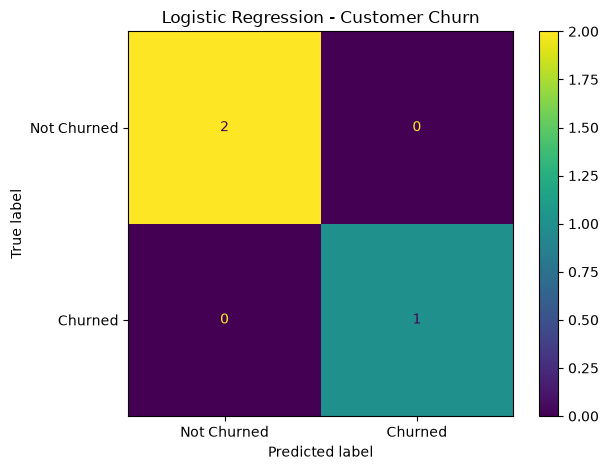

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Churned", "Churned"]
)

plt.title("Logistic Regression - Customer Churn")
plt.tight_layout()

plt.savefig(
    "../outputs/confusion_matrix.png",
    dpi=300
)

plt.show()

In [25]:
# Recalculate the non-ML majority-class baseline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Actual target values from the complete dataset
y_all = df["churned"]

# Majority class
majority_class = y_all.mode()[0]

# Predict majority class for every customer
baseline_predictions = np.full(
    len(y_all),
    majority_class
)

# Calculate baseline metrics
baseline_accuracy = accuracy_score(
    y_all,
    baseline_predictions
)

baseline_precision = precision_score(
    y_all,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_all,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_all,
    baseline_predictions,
    zero_division=0
)

print("Non-ML Baseline")
print("=" * 40)
print("Majority Class:", majority_class)
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

Non-ML Baseline
Majority Class: 0
Accuracy : 0.5833
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


In [26]:
# Compare Non-ML Baseline and Logistic Regression

comparison = pd.DataFrame({
    "Model": [
        "Majority Class Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy
    ],
    "Precision": [
        baseline_precision,
        precision
    ],
    "Recall": [
        baseline_recall,
        recall
    ],
    "F1 Score": [
        baseline_f1,
        f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Class Baseline,0.583333,0.0,0.0,0.0
1,Logistic Regression,1.000000,1.0,1.0,1.0


In [27]:
comparison.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


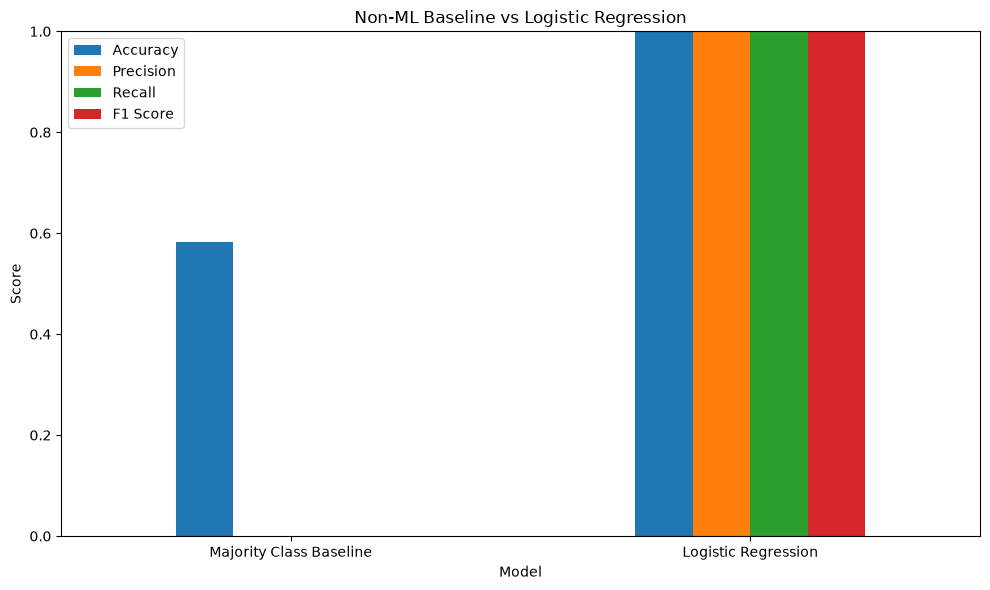

In [28]:
comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Non-ML Baseline vs Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../outputs/model_comparison.png",
    dpi=300
)

plt.show()

## Model Comparison Interpretation

The majority-class non-ML baseline achieves 58.33% accuracy on the
complete dataset but has zero recall for the churned class because it
predicts every customer as not churned.

The Logistic Regression model correctly classified all three records
in the held-out test set, resulting in 100% accuracy, precision,
recall and F1-score for this particular split.

However, the test set contains only three observations. Therefore,
the 100% test metrics have very high uncertainty and should not be
interpreted as evidence that the model is perfect or production-ready.

The results demonstrate the mechanics of building and evaluating an
ML baseline, but a much larger and representative dataset would be
required for reliable model validation.

## Limitations of the Experiment

1. The dataset contains only 12 customer records.
2. Only 9 records are used for training.
3. Only 3 records are used for testing.
4. A single train/test split can produce unstable results on such a
   small dataset.
5. The dataset documentation does not establish that the records are
   representative of a broader customer population.
6. The original data collection process and consent information are
   not documented in the supplied materials.
7. Temporal information is not available for establishing a robust
   time-based validation strategy.
8. Subgroup fairness cannot be meaningfully evaluated because the
   required subgroup information is not provided.

Therefore, this experiment is an educational ML baseline and should
not be used for production customer decisions.